<a href="https://colab.research.google.com/github/k4urman/xternchallenge2026/blob/main/LargeLoadByState.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Q4 How is large load growing state by state across MISO?
# EIA API v2 - retail electricity sales by state and sector
# ============================================================
# Get your OWN key (free, instant): https://www.eia.gov/opendata/register.php
# Do not paste a shared key into a notebook you push anywhere.

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/GI Interactive Queue (1)(in).csv')
df.columns = [c.strip() for c in df.columns]
print(df.shape)
print(df[['County', 'State', 'Summer MW']].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3822, 24)
                           County State  Summer MW
0                    Grant County    WI       50.0
1                  Lincoln County    MN       40.0
2                 Waushara County    WI       99.0
3                    Dodge County    WI       50.0
4  Mecosta County,Montcalm County    MI      800.0


In [ ]:
API_KEY = 'fLslAuaT4Tm64qipqKjYRRtBhNfTWb8bTJSkAJuf'  # Zach's key

In [ ]:
# MISO footprint. TX and KY are partial - MISO covers only a slice of
# each, but EIA reports whole states. Note that or drop them.
MISO_STATES = ['IL', 'IN', 'IA', 'MI', 'MN', 'MO', 'MT', 'ND',
               'SD', 'WI', 'AR', 'LA', 'MS', 'TX', 'KY']

In [ ]:
# Large loads land in both commercial and industrial, so pull both.
SECTORS = ['COM', 'IND']

START, END = 2020, 2024

# MISO published range: load addition requests imply a 5-year CAGR
# of 3.1% to 5.1% across the footprint.
CAGR_LOW, CAGR_HIGH = 0.031, 0.051

In [ ]:
# ============================================================
# 1. PULL
# ============================================================
URL = 'https://api.eia.gov/v2/electricity/retail-sales/data/'

def pull_eia(offset=0, length=5000):
    params = {
        'api_key': API_KEY,
        'frequency': 'annual',
        'data[0]': 'sales',
        'start': START,
        'end': END,
        'offset': offset,
        'length': length,
    }
    # facets go in as repeated params, so build them as a list of tuples
    pairs = list(params.items())
    pairs += [('facets[stateid][]', s) for s in MISO_STATES]
    pairs += [('facets[sectorid][]', s) for s in SECTORS]

    r = requests.get(URL, params=pairs, timeout=60)
    if r.status_code != 200:
        print('FAILED', r.status_code)
        print(r.text[:500])
        return None
    return r.json()

In [ ]:
first = pull_eia()
print('total rows available:', first['response']['total'])

total rows available: 150


In [ ]:
rows = first['response']['data']
total = int(first['response']['total'])

# page through if there is more
off = len(rows)
while off < total:
    nxt = pull_eia(offset=off)
    if nxt is None:
        break
    rows += nxt['response']['data']
    off = len(rows)

raw = pd.DataFrame(rows)
print(raw.shape)
raw.head()

(150, 7)


,period,stateid,stateDescription,sectorid,sectorName,sales,sales-units
0,2024,AR,Arkansas,COM,commercial,11789.053,million kilowatt hours
1,2024,AR,Arkansas,IND,industrial,19525.858,million kilowatt hours
2,2024,IA,Iowa,COM,commercial,12814.98901,million kilowatt hours
3,2024,IA,Iowa,IND,industrial,27646.58298,million kilowatt hours
4,2024,IL,Illinois,COM,commercial,45240.21401,million kilowatt hours


In [ ]:
# ============================================================
# 2. CLEAN
# ============================================================
# 'sales' comes back as million kilowatthours. Divide by 1000 for TWh.
print('units check:', raw['sales-units'].unique())

eia = raw[['period', 'stateid', 'sectorid', 'sales']].copy()
eia.columns = ['YEAR', 'STATE', 'SECTOR', 'SALES_MKWH']

eia['YEAR'] = pd.to_numeric(eia['YEAR'], errors='coerce')
eia['SALES_MKWH'] = pd.to_numeric(eia['SALES_MKWH'], errors='coerce')
eia['TWH'] = eia['SALES_MKWH'] / 1000

print('nulls:\n', eia.isna().sum())
print('states:', sorted(eia['STATE'].unique()))
print('years:', sorted(eia['YEAR'].unique()))

eia = eia.dropna(subset=['TWH'])

# commercial + industrial combined = our large load proxy
Load4 = eia.pivot_table(index=['STATE', 'YEAR'], columns='SECTOR',
                        values='TWH', aggfunc='sum').reset_index()
Load4.columns.name = None
Load4['LARGE_TWH'] = Load4['COM'] + Load4['IND']
Load4.head(10)


units check: ['million kilowatt hours']
nulls:
 YEAR          0
STATE         0
SECTOR        0
SALES_MKWH    0
TWH           0
dtype: int64
states: ['AR', 'IA', 'IL', 'IN', 'KY', 'LA', 'MI', 'MN', 'MO', 'MS', 'MT', 'ND', 'SD', 'TX', 'WI']
years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,STATE,YEAR,COM,IND,LARGE_TWH
0,AR,2020,11.110416,16.760182,27.870598
1,AR,2021,11.516908,18.228014,29.744922
2,AR,2022,11.786525,17.960258,29.746783
3,AR,2023,11.694057,18.581004,30.275061
4,AR,2024,11.789053,19.525858,31.314911
5,IA,2020,11.605738,24.466641,36.072379
6,IA,2021,12.135097,26.106417,38.241514
7,IA,2022,12.470072,26.541024,39.011096
8,IA,2023,12.600924,27.217490,39.818414
9,IA,2024,12.814989,27.646583,40.461572


YEAR   CHANGE_TWH   PCT
STATE                  
IL            2.1   2.4
IN            1.9   2.9
MN            1.4   3.4
WI            1.7   3.8
MO            1.8   4.3
KY            2.5   5.4
MS            1.6   5.6
MI            4.3   7.1
MT            0.7   7.2
LA            5.7   9.7
SD            0.8  11.0
IA            4.4  12.2
AR            3.4  12.4
TX           70.1  25.9
ND            8.1  48.2


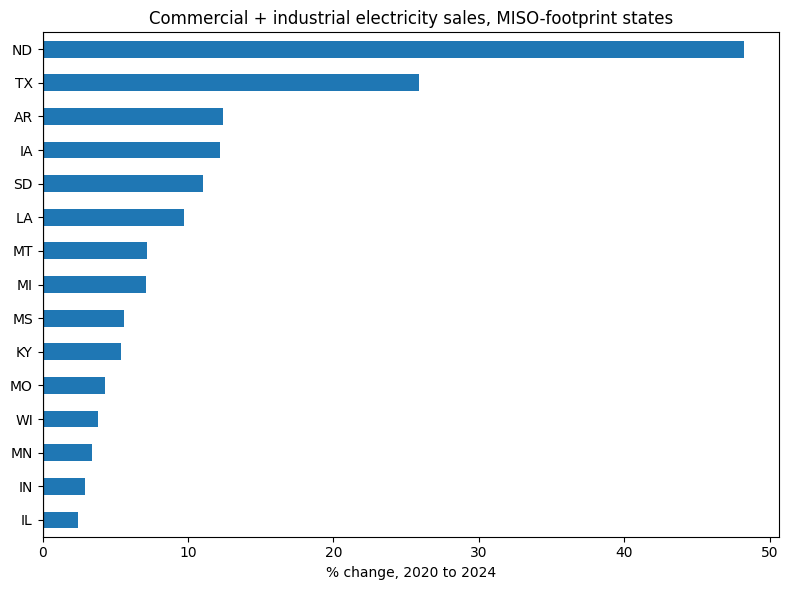

In [ ]:
# ============================================================
# 3. MEASURED GROWTH, 2020 to 2024
# ============================================================
Wide4 = Load4.pivot(index='STATE', columns='YEAR', values='LARGE_TWH').dropna()
Wide4['CHANGE_TWH'] = Wide4[END] - Wide4[START]
Wide4['PCT'] = ((Wide4[END] / Wide4[START] - 1) * 100).round(1)
Wide4 = Wide4.sort_values('PCT')

print(Wide4[['CHANGE_TWH', 'PCT']].round(1))

colors = ['tab:red' if v < 0 else 'tab:blue' for v in Wide4['PCT']]
ax = Wide4['PCT'].plot(kind='barh', figsize=(8, 6), color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'% change, {START} to {END}')
ax.set_ylabel('')
ax.set_title('Commercial + industrial electricity sales, MISO-footprint states')
plt.tight_layout()
plt.show()

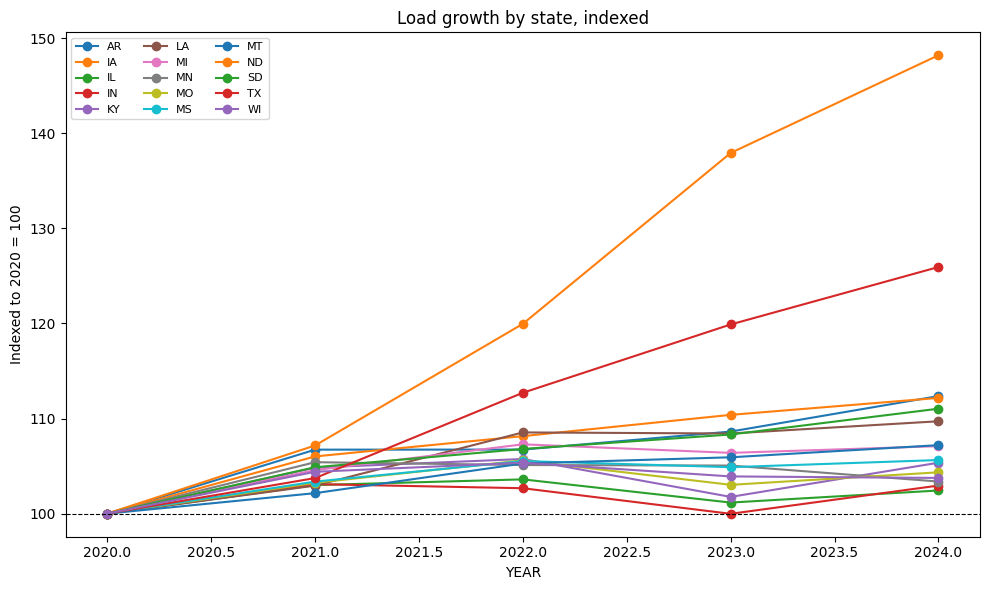

In [ ]:
# ---- indexed lines so big and small states are comparable ----
Idx4 = Load4.pivot(index='YEAR', columns='STATE', values='LARGE_TWH')
Idx4 = Idx4 / Idx4.loc[START] * 100

ax = Idx4.plot(figsize=(10, 6), marker='o')
ax.axhline(100, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel(f'Indexed to {START} = 100')
ax.set_title('Load growth by state, indexed')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


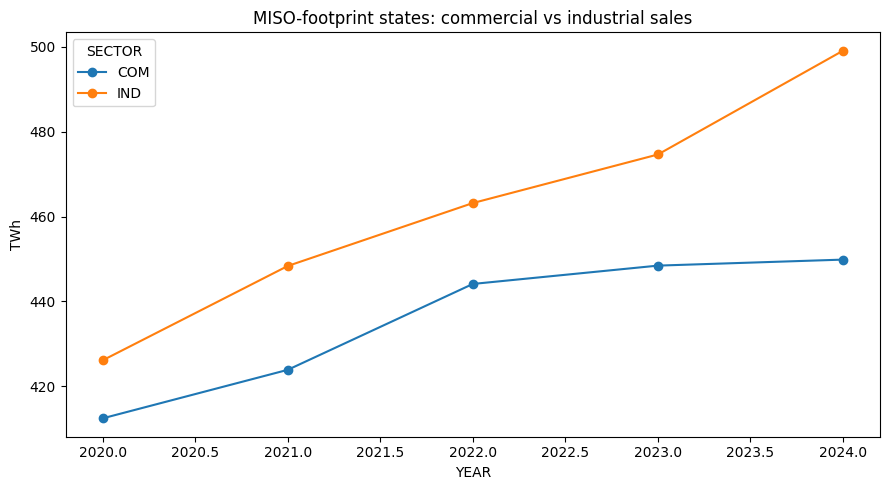

SECTOR    COM    IND
YEAR                
2020    412.4  426.1
2021    423.9  448.4
2022    444.1  463.2
2023    448.4  474.6
2024    449.9  499.1


In [ ]:
# ---- industrial vs commercial split ----
Split4 = eia.groupby(['YEAR', 'SECTOR'])['TWH'].sum().unstack()
ax = Split4.plot(figsize=(9, 5), marker='o')
ax.set_ylabel('TWh')
ax.set_title('MISO-footprint states: commercial vs industrial sales')
plt.tight_layout()
plt.show()
print(Split4.round(1))

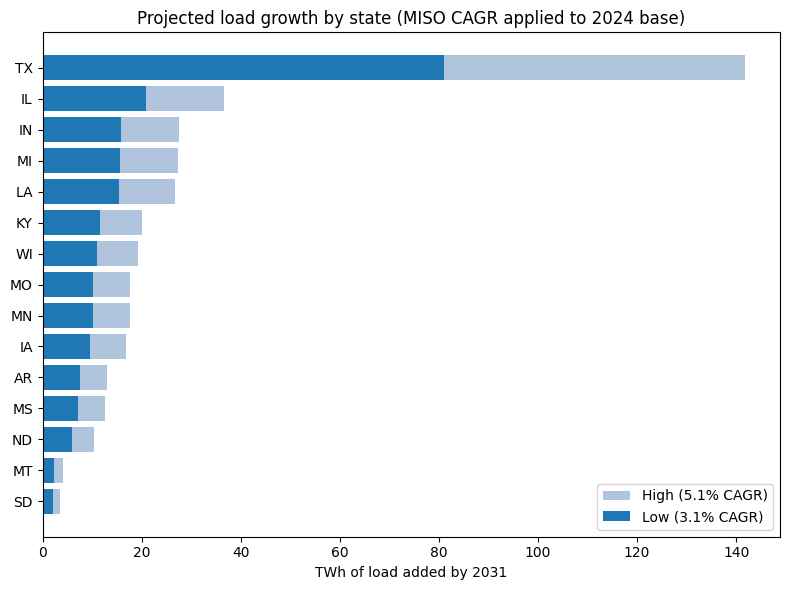

In [ ]:
# ============================================================
# 4. PROJECTED FORWARD using MISO's published CAGR range
#    This is an ALLOCATION, not a measurement. It assumes growth
#    spreads in proportion to existing load, which is not true -
#    data centers cluster. Label the chart accordingly.
# ============================================================
Base4 = Load4[Load4['YEAR'] == END][['STATE', 'LARGE_TWH']].copy()

for label, r in [('LOW', CAGR_LOW), ('HIGH', CAGR_HIGH)]:
    Base4[f'ADD_{label}'] = Base4['LARGE_TWH'] * ((1 + r) ** 7 - 1)

Base4 = Base4.sort_values('ADD_HIGH')

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(Base4))
ax.barh(y, Base4['ADD_HIGH'], color='lightsteelblue',
        label=f'High ({CAGR_HIGH:.1%} CAGR)')
ax.barh(y, Base4['ADD_LOW'], color='tab:blue',
        label=f'Low ({CAGR_LOW:.1%} CAGR)')
ax.set_yticks(y)
ax.set_yticklabels(Base4['STATE'])
ax.set_xlabel('TWh of load added by 2031')
ax.set_title('Projected load growth by state (MISO CAGR applied to 2024 base)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(Base4[['STATE', 'LARGE_TWH', 'ADD_LOW', 'ADD_HIGH']].round(1))

   STATE  LARGE_TWH  ADD_LOW  ADD_HIGH
64    SD        8.5      2.0       3.5
54    MT        9.9      2.4       4.1
59    ND       24.9      5.9      10.4
49    MS       30.1      7.2      12.5
4     AR       31.3      7.5      13.0
9     IA       40.5      9.6      16.9
39    MN       42.5     10.1      17.7
44    MO       42.5     10.1      17.7
74    WI       46.3     11.0      19.3
24    KY       48.3     11.5      20.1
29    LA       64.4     15.3      26.8
34    MI       65.5     15.6      27.3
19    IN       66.2     15.8      27.6
14    IL       87.9     21.0      36.6
69    TX      340.4     81.1     141.8


In [ ]:

# ============================================================
# Q5 3D map: where is load growth concentrated in MISO?
# pydeck ColumnLayer, state level
# ============================================================
# Run after the EIA script. Needs Base4 in memory.

!pip install pydeck -q

import pydeck as pdk
import pandas as pd
import numpy as np

# State centroids. Roughly the population center, not the geographic one,
# so columns sit where the load actually is.
CENTROIDS = {
    'IL': (40.0, -89.2), 'IN': (39.9, -86.3), 'IA': (42.0, -93.5),
    'MI': (43.3, -84.5), 'MN': (46.0, -94.3), 'MO': (38.4, -92.5),
    'MT': (46.9, -110.4), 'ND': (47.5, -100.5), 'SD': (44.4, -100.2),
    'WI': (44.6, -89.8), 'AR': (34.8, -92.4), 'LA': (31.1, -92.0),
    'MS': (32.7, -89.7), 'TX': (31.5, -99.3), 'KY': (37.7, -85.3),
}

Map5 = Base4.copy()
Map5['LAT'] = Map5['STATE'].map(lambda s: CENTROIDS.get(s, (None, None))[0])
Map5['LON'] = Map5['STATE'].map(lambda s: CENTROIDS.get(s, (None, None))[1])
Map5 = Map5.dropna(subset=['LAT', 'LON'])

# scale column height so the tallest is readable at this zoom
VALUE = 'ADD_HIGH'
Map5['HEIGHT'] = Map5[VALUE] / Map5[VALUE].max() * 250_000

# color: white at the low end, red at the high end
def to_color(v, lo, hi):
    t = (v - lo) / (hi - lo) if hi > lo else 0
    return [255, int(255 * (1 - t)), int(255 * (1 - t)), 200]

lo, hi = Map5[VALUE].min(), Map5[VALUE].max()
Map5['COLOR'] = Map5[VALUE].map(lambda v: to_color(v, lo, hi))

layer = pdk.Layer(
    'ColumnLayer',
    data=Map5,
    get_position=['LON', 'LAT'],
    get_elevation='HEIGHT',
    elevation_scale=1,
    radius=45_000,
    get_fill_color='COLOR',
    pickable=True,
    auto_highlight=True,
)

view = pdk.ViewState(latitude=41.0, longitude=-92.0,
                     zoom=4.0, pitch=50, bearing=-15)

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    map_style='light',
    tooltip={'text': '{STATE}\n+{ADD_HIGH} TWh by 2031'},
)

deck.to_html('miso_load_map.html')
deck

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "initialViewState": {
    "bearing": -15,
    "latitude": 41.0,
    "longitude": -92.0,
    "pitch": 50,
    "zoom": 4.0
  },
  "layers": [
    {
      "@@type": "ColumnLayer",
      "autoHighlight": true,
      "data": [
        {
          "ADD_HIGH": 3.526629761090222,
          "ADD_LOW": 2.0173514061799445,
          "COLOR": [
            255,
            255,
            255,
            200
          ],
          "HEIGHT": 6219.103977213893,
          "LARGE_TWH": 8.467137000000001,
          "LAT": 44.4,
          "LON": -100.2,
          "STATE": "SD"
        },
        {
          "ADD_HIGH": 4.109588846984724,
          "ADD_LOW": 2.3508237044773104,
          "COLOR": [
            255,
            253,
            253,
            200
          ],
          "HEIGHT": 7247.134537620293,
          "LARGE_TWH": 9.866772000000001,
          "LAT": 46.9,
          "LON": -110.4,
          "STATE": "MT"
        },
        {
          "ADD_HIGH": 10.35394706006431,
          "ADD_LOW": 5.92280763112379,
          "COLOR": [
            255,
            242,
            242,
            200
          ],
          "HEIGHT": 18258.86971509077,
          "LARGE_TWH": 24.85894301,
          "LAT": 47.5,
          "LON": -100.5,
          "STATE": "ND"
        },
        {
          "ADD_HIGH": 12.533311514426927,
          "ADD_LOW": 7.169477750877973,
          "COLOR": [
            255,
            238,
            238,
            200
          ],
          "HEIGHT": 22102.112432391248,
          "LARGE_TWH": 30.09141102,
          "LAT": 32.7,
          "LON": -89.7,
          "STATE": "MS"
        },
        {
          "ADD_HIGH": 13.042908966571765,
          "ADD_LOW": 7.46098471540614,
          "COLOR": [
            255,
            237,
            237,
            200
          ],
          "HEIGHT": 23000.771990130674,
          "LARGE_TWH": 31.314911,
          "LAT": 34.8,
          "LON": -92.4,
          "STATE": "AR"
        },
        {
          "ADD_HIGH": 16.85256586263202,
          "ADD_LOW": 9.640237207721752,
          "COLOR": [
            255,
            230,
            230,
            200
          ],
          "HEIGHT": 29718.985683984465,
          "LARGE_TWH": 40.461571989999996,
          "LAT": 42.0,
          "LON": -93.5,
          "STATE": "IA"
        },
        {
          "ADD_HIGH": 17.69493067721624,
          "ADD_LOW": 10.12209834947445,
          "COLOR": [
            255,
            228,
            228,
            200
          ],
          "HEIGHT": 31204.47033180479,
          "LARGE_TWH": 42.484018,
          "LAT": 46.0,
          "LON": -94.3,
          "STATE": "MN"
        },
        {
          "ADD_HIGH": 17.71146479694199,
          "ADD_LOW": 10.131556424729954,
          "COLOR": [
            255,
            228,
            228,
            200
          ],
          "HEIGHT": 31233.62774744298,
          "LARGE_TWH": 42.523715010000004,
          "LAT": 38.4,
          "LON": -92.5,
          "STATE": "MO"
        },
        {
          "ADD_HIGH": 19.273304159253385,
          "ADD_LOW": 11.024981322503189,
          "COLOR": [
            255,
            225,
            225,
            200
          ],
          "HEIGHT": 33987.883807176695,
          "LARGE_TWH": 46.27355799,
          "LAT": 44.6,
          "LON": -89.8,
          "STATE": "WI"
        },
        {
          "ADD_HIGH": 20.125730968405794,
          "ADD_LOW": 11.512598265195095,
          "COLOR": [
            255,
            224,
            224,
            200
          ],
          "HEIGHT": 35491.1124754009,
          "LARGE_TWH": 48.32016199,
          "LAT": 37.7,
          "LON": -85.3,
          "STATE": "KY"
        },
        {
          "ADD_HIGH": 26.811433482218643,
          "ADD_LOW": 15.337046047139644,
          "COLOR": [
            255,
            212,
            212,
            200
          ],
          "HEIGHT": 47281.14486067422,
          "LARGE

In [ ]:
# ============================================================
# CELL 1: 3D map, restyled
# ============================================================
!pip install pydeck -q

import pydeck as pdk
import pandas as pd
import numpy as np

START, END = 2020, 2024
DROP = ['TX', 'KY']

CENTROIDS = {
    'IL': (40.0, -89.2), 'IN': (39.9, -86.3), 'IA': (42.0, -93.5),
    'MI': (43.3, -84.5), 'MN': (46.0, -94.3), 'MO': (38.4, -92.5),
    'MT': (46.9, -110.4), 'ND': (47.5, -100.5), 'SD': (44.4, -100.2),
    'WI': (44.6, -89.8), 'AR': (34.8, -92.4), 'LA': (31.1, -92.0),
    'MS': (32.7, -89.7),
}

W = Load4.pivot(index='STATE', columns='YEAR', values='LARGE_TWH').dropna()
W['PCT'] = ((W[END] / W[START] - 1) * 100).round(1)
W['BASE_TWH'] = W[END].round(1)

Map5 = W[['PCT', 'BASE_TWH']].reset_index()
Map5 = Map5[~Map5['STATE'].isin(DROP)]
Map5 = Map5[Map5['STATE'].isin(CENTROIDS)]
Map5['LAT'] = Map5['STATE'].map(lambda s: CENTROIDS[s][0])
Map5['LON'] = Map5['STATE'].map(lambda s: CENTROIDS[s][1])

V = Map5['PCT'].clip(lower=0)
lo, hi = V.min(), V.max()
span = (hi - lo) if hi > lo else 1
Map5['NORM'] = (V - lo) / span

# taller and thinner reads much better than short and fat
Map5['HEIGHT'] = (Map5['NORM'] * 0.88 + 0.12) * 420_000


# ---- color ramp: deep violet -> magenta -> hot orange ----
# glows against a dark basemap the way the reference images do
RAMP = [
    (0.00, (35, 25, 90)),
    (0.35, (90, 40, 165)),
    (0.65, (190, 55, 140)),
    (1.00, (255, 140, 60)),
]

def ramp_color(t, alpha=220):
    if t <= 0:
        return list(RAMP[0][1]) + [alpha]
    for (p0, c0), (p1, c1) in zip(RAMP, RAMP[1:]):
        if t <= p1:
            f = (t - p0) / (p1 - p0)
            return [int(a + (b - a) * f) for a, b in zip(c0, c1)] + [alpha]
    return list(RAMP[-1][1]) + [alpha]

Map5['COLOR'] = Map5['NORM'].map(lambda t: ramp_color(t))
Map5['GLOW'] = Map5['NORM'].map(lambda t: ramp_color(t, alpha=45))
Map5['GLOW_R'] = 110_000 + Map5['NORM'] * 90_000
Map5['LABEL'] = Map5['STATE'] + '  ' + Map5['PCT'].astype(str) + '%'


# ---- soft halo under each column ----
glow = pdk.Layer(
    'ScatterplotLayer',
    data=Map5,
    get_position=['LON', 'LAT'],
    get_radius='GLOW_R',
    get_fill_color='GLOW',
    stroked=False,
)

# ---- the columns ----
cols = pdk.Layer(
    'ColumnLayer',
    data=Map5,
    get_position=['LON', 'LAT'],
    get_elevation='HEIGHT',
    elevation_scale=1,
    radius=26_000,
    get_fill_color='COLOR',
    disk_resolution=40,
    extruded=True,
    pickable=True,
    auto_highlight=True,
)

# ---- labels floating above the columns ----
labels = pdk.Layer(
    'TextLayer',
    data=Map5,
    get_position=['LON', 'LAT'],
    get_text='LABEL',
    get_size=13,
    get_color=[235, 235, 245, 230],
    get_alignment_baseline="'bottom'",
    get_pixel_offset=[0, -8],
    billboard=True,
)

deck = pdk.Deck(
    layers=[glow, cols, labels],
    initial_view_state=pdk.ViewState(
        latitude=40.6, longitude=-91.5,
        zoom=4.3, pitch=58, bearing=-18,
    ),
    map_style='dark',
    tooltip={'text': '{STATE}\n{PCT}% growth {START}-{END}\n'
                     '{BASE_TWH} TWh in 2024'},
)

deck.to_html('miso_load_map.html')
deck

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "initialViewState": {
    "bearing": -18,
    "latitude": 40.6,
    "longitude": -91.5,
    "pitch": 58,
    "zoom": 4.3
  },
  "layers": [
    {
      "@@type": "ScatterplotLayer",
      "data": [
        {
          "BASE_TWH": 31.3,
          "COLOR": [
            69,
            34,
            136,
            220
          ],
          "GLOW": [
            69,
            34,
            136,
            45
          ],
          "GLOW_R": 129650.65502183406,
          "HEIGHT": 131098.6899563319,
          "LABEL": "AR  12.4%",
          "LAT": 34.8,
          "LON": -92.4,
          "NORM": 0.21834061135371177,
          "PCT": 12.4,
          "STATE": "AR"
        },
        {
          "BASE_TWH": 40.5,
          "COLOR": [
            68,
            34,
            135,
            220
          ],
          "GLOW": [
            68,
            34,
            135,
            45
          ],
          "GLOW_R": 129257.64192139737,
          "HEIGHT": 129484.7161572052,
          "LABEL": "IA  12.2%",
          "LAT": 42.0,
          "LON": -93.5,
          "NORM": 0.2139737991266375,
          "PCT": 12.2,
          "STATE": "IA"
        },
        {
          "BASE_TWH": 87.9,
          "COLOR": [
            35,
            25,
            90,
            220
          ],
          "GLOW": [
            35,
            25,
            90,
            45
          ],
          "GLOW_R": 110000.0,
          "HEIGHT": 50400.0,
          "LABEL": "IL  2.4%",
          "LAT": 40.0,
          "LON": -89.2,
          "NORM": 0.0,
          "PCT": 2.4,
          "STATE": "IL"
        },
        {
          "BASE_TWH": 66.2,
          "COLOR": [
            36,
            25,
            92,
            220
          ],
          "GLOW": [
            36,
            25,
            92,
            45
          ],
          "GLOW_R": 110982.5327510917,
          "HEIGHT": 54434.9344978166,
          "LABEL": "IN  2.9%",
          "LAT": 39.9,
          "LON": -86.3,
          "NORM": 0.010917030567685589,
          "PCT": 2.9,
          "STATE": "IN"
        },
        {
          "BASE_TWH": 64.4,
          "COLOR": [
            60,
            31,
            124,
            220
          ],
          "GLOW": [
            60,
            31,
            124,
            45
          ],
          "GLOW_R": 124344.97816593887,
          "HEIGHT": 109310.04366812223,
          "LABEL": "LA  9.7%",
          "LAT": 31.1,
          "LON": -92.0,
          "NORM": 0.15938864628820956,
          "PCT": 9.7,
          "STATE": "LA"
        },
        {
          "BASE_TWH": 65.5,
          "COLOR": [
            51,
            29,
            111,
            220
          ],
          "GLOW": [
            51,
            29,
            111,
            45
          ],
          "GLOW_R": 119235.80786026201,
          "HEIGHT": 88328.38427947598,
          "LABEL": "MI  7.1%",
          "LAT": 43.3,
          "LON": -84.5,
          "NORM": 0.10262008733624452,
          "PCT": 7.1,
          "STATE": "MI"
        },
        {
          "BASE_TWH": 42.5,
          "COLOR": [
            38,
            25,
            94,
            220
          ],
          "GLOW": [
            38,
            25,
            94,
            45
          ],
          "GLOW_R": 111965.06550218341,
          "HEIGHT": 58469.86899563319,
          "LABEL": "MN  3.4%",
          "LAT": 46.0,
          "LON": -94.3,
          "NORM": 0.021834061135371178,
          "PCT": 3.4,
          "STATE": "MN"
        },
        {
          "BASE_TWH": 42.5,
          "COLOR": [
            41,
            26,
            98,
            220
          ],
          "GLOW": [
            41,
            26,
            98,
            45
          ],
          "GLOW_R": 113733.62445414848,
          "HEIGHT": 65732.75109170304,
          "LABEL": "MO  4.3%",
          "LAT": 38.4,
          "LON": -92.5,
          "NORM": 0.04148471615720523,

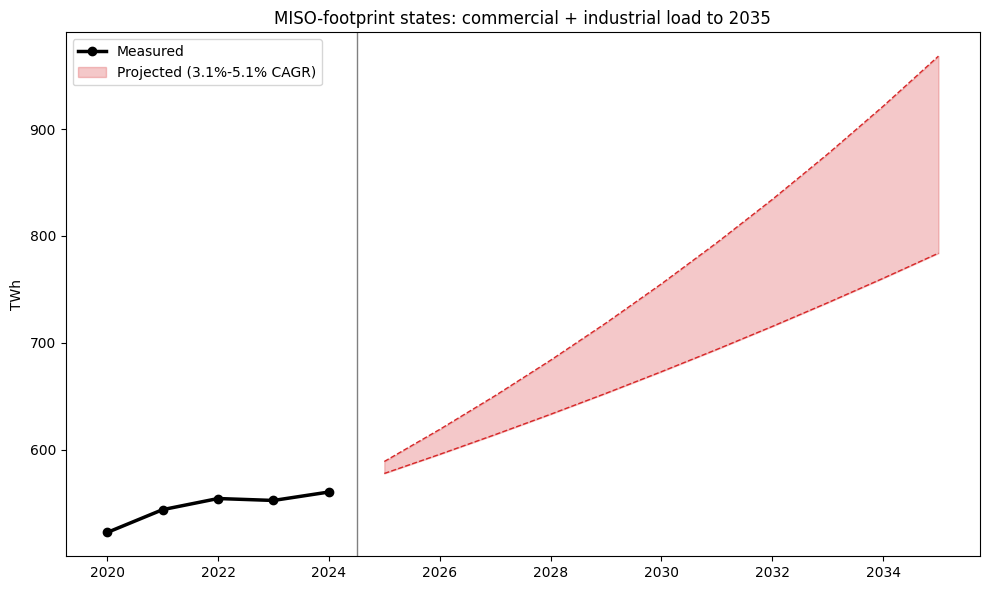

2024 measured:  560.3 TWh
2035 low:       783.9 TWh
2035 high:      968.4 TWh
added by 2035:  223.6 to 408.1 TWh


In [ ]:

# ---- chart B: footprint total with the low-high band ----
TotH = hist.groupby('YEAR')['LARGE_TWH'].sum()
TotL = proj.groupby('YEAR')['LOW'].sum()
TotHi = proj.groupby('YEAR')['HIGH'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(TotH.index, TotH.values, color='black', linewidth=2.5,
        marker='o', label='Measured')
ax.fill_between(TotL.index, TotL.values, TotHi.values,
                color='tab:red', alpha=0.25,
                label=f'Projected ({CAGR_LOW:.1%}-{CAGR_HIGH:.1%} CAGR)')
ax.plot(TotL.index, TotL.values, color='tab:red', linewidth=1, linestyle='--')
ax.plot(TotHi.index, TotHi.values, color='tab:red', linewidth=1, linestyle='--')
ax.axvline(END + 0.5, color='gray', linewidth=1)
ax.set_ylabel('TWh')
ax.set_title('MISO-footprint states: commercial + industrial load to 2035')
ax.legend()
plt.tight_layout()
plt.show()

print('2024 measured: ', round(TotH.loc[END], 1), 'TWh')
print('2035 low:      ', round(TotL.loc[2035], 1), 'TWh')
print('2035 high:     ', round(TotHi.loc[2035], 1), 'TWh')
print('added by 2035: ', round(TotL.loc[2035] - TotH.loc[END], 1), 'to',
      round(TotHi.loc[2035] - TotH.loc[END], 1), 'TWh')


In [ ]:

# ============================================================
# CELL: county-level 3D map of MISO queue capacity
# ============================================================
# Uses df (the GI queue) - it has County, State, SUMMER_MW.
# Geometry comes from the standard plotly county geojson, and
# centroids are computed from it so there is no second file to match.

!pip install pydeck -q

import json
import pydeck as pdk
import pandas as pd
import numpy as np
from urllib.request import urlopen

GEOJSON = ('https://raw.githubusercontent.com/plotly/datasets/master/'
           'geojson-counties-fips.json')

with urlopen(GEOJSON) as r:
    counties = json.load(r)

print('counties in file:', len(counties['features']))


# ---- compute a centroid for each county from its polygon ----
def poly_centroid(geom):
    """Mean of the exterior ring coordinates. Good enough for a map."""
    t = geom['type']
    if t == 'Polygon':
        ring = geom['coordinates'][0]
    elif t == 'MultiPolygon':
        # take the largest piece by vertex count
        ring = max((p[0] for p in geom['coordinates']), key=len)
    else:
        return None, None
    arr = np.array(ring, dtype=float)
    return float(arr[:, 1].mean()), float(arr[:, 0].mean())


STATE_FIPS = {
    '17': 'IL', '18': 'IN', '19': 'IA', '26': 'MI', '27': 'MN',
    '29': 'MO', '30': 'MT', '38': 'ND', '46': 'SD', '55': 'WI',
    '05': 'AR', '22': 'LA', '28': 'MS',
}

rows = []
for f in counties['features']:
    p = f['properties']
    st = STATE_FIPS.get(p.get('STATE'))
    if not st:
        continue
    lat, lon = poly_centroid(f['geometry'])
    if lat is None:
        continue
    rows.append({'STATE': st,
                 'CNAME': str(p['NAME']).upper().strip(),
                 'LAT': lat, 'LON': lon})

Geo = pd.DataFrame(rows)
print('MISO-state counties with centroids:', len(Geo))
Geo.head()


# ---- clean the queue county names to match ----
def clean_county(s):
    s = str(s).upper().strip()
    for junk in [' COUNTY', ' PARISH', '.', ',']:
        s = s.replace(junk, '')
    s = s.replace('SAINT ', 'ST ').replace('ST. ', 'ST ')
    return s.strip()

q = df.copy()
q['CNAME'] = q['County'].map(clean_county)
q['STATE'] = q['State'].astype(str).str.upper().str.strip()
q['MW'] = pd.to_numeric(q['Summer MW'], errors='coerce')

Cty = (q.dropna(subset=['MW'])
         .groupby(['STATE', 'CNAME'])
         .agg(MW=('MW', 'sum'), PROJECTS=('MW', 'count'))
         .reset_index())

# same cleaning on the geo side so the join has a chance
Geo['CNAME'] = Geo['CNAME'].map(clean_county)

Map6 = Cty.merge(Geo, on=['STATE', 'CNAME'], how='left')

matched = Map6['LAT'].notna().sum()
print(f'matched {matched} of {len(Map6)} counties '
      f'({matched/len(Map6):.0%})')
print('\nUNMATCHED - fix these by hand if the rate is low:')
print(Map6[Map6['LAT'].isna()].sort_values('MW', ascending=False)
      [['STATE', 'CNAME', 'MW']].head(20))

Map6 = Map6.dropna(subset=['LAT'])
Map6['MW'] = Map6['MW'].round(0)


# ---- height: log scale, because a few counties dwarf the rest ----
V = np.log1p(Map6['MW'].clip(lower=0))
lo, hi = V.min(), V.max()
Map6['NORM'] = (V - lo) / (hi - lo if hi > lo else 1)
Map6['HEIGHT'] = (Map6['NORM'] * 0.93 + 0.07) * 320_000


# ---- violet to orange ramp ----
RAMP = [(0.00, (30, 22, 80)), (0.35, (95, 40, 170)),
        (0.65, (200, 55, 135)), (1.00, (255, 150, 55))]

def ramp_color(t, alpha=225):
    if t <= 0:
        return list(RAMP[0][1]) + [alpha]
    for (p0, c0), (p1, c1) in zip(RAMP, RAMP[1:]):
        if t <= p1:
            f = (t - p0) / (p1 - p0)
            return [int(a + (b - a) * f) for a, b in zip(c0, c1)] + [alpha]
    return list(RAMP[-1][1]) + [alpha]

Map6['COLOR'] = Map6['NORM'].map(ramp_color)


cols = pdk.Layer(
    'ColumnLayer',
    data=Map6,
    get_position=['LON', 'LAT'],
    get_elevation='HEIGHT',
    elevation_scale=1,
    radius=11_000,
    get_fill_color='COLOR',
    disk_resolution=24,
    extruded=True,
    pickable=True,
    auto_highlight=True,
)

deck = pdk.Deck(
    layers=[cols],
    initial_view_state=pdk.ViewState(
        latitude=40.5, longitude=-91.0,
        zoom=4.4, pitch=58, bearing=-18,
    ),
    map_style='dark',
    tooltip={'text': '{CNAME}, {STATE}\n{MW} MW in queue\n'
                     '{PROJECTS} projects'},
)

deck.to_html('miso_county_map.html')
deck

counties in file: 3221
MISO-state counties with centroids: 1046
matched 611 of 756 counties (81%)

UNMATCHED - fix these by hand if the rate is low:
    STATE            CNAME       MW
622   NAN              NAN  32325.7
291    KY        HENDERSON   4164.0
688    TX        JEFFERSON   2745.6
689    TX          LIBERTY   2663.3
633   NAN       ST CHARLES   2220.0
298    KY          WEBSTER   1430.0
696    TX             POLK   1325.0
724    WI    KENOSHARACINE   1200.0
237    IN     JASPERSTARKE   1197.0
623   NAN           ORANGE   1166.0
692    TX              NAN   1166.0
613   NAN             LINN   1164.0
684    TX           HARDIN   1131.0
405    MI  MECOSTAMONTCALM   1050.0
637   NAN       VERMILLION   1040.0
34     AR              NAN   1025.0
694    TX           ORANGE   1016.7
411    MI              NAN    952.0
700    TX           WALKER    925.0
634   NAN         ST LOUIS    922.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{
  "initialViewState": {
    "bearing": -18,
    "latitude": 40.5,
    "longitude": -91.0,
    "pitch": 58,
    "zoom": 4.4
  },
  "layers": [
    {
      "@@type": "ColumnLayer",
      "autoHighlight": true,
      "data": [
        {
          "CNAME": "ARKANSAS",
          "COLOR": [
            230,
            108,
            90,
            225
          ],
          "HEIGHT": 274074.568615597,
          "LAT": 34.23330640909091,
          "LON": -91.36780768181818,
          "MW": 2567.0,
          "NORM": 0.8456806741115488,
          "PROJECTS": 19,
          "STATE": "AR"
        },
        {
          "CNAME": "ASHLEY",
          "COLOR": [
            206,
            66,
            125,
            225
          ],
          "HEIGHT": 228293.51939219193,
          "LAT": 33.08762511111111,
          "LON": -91.76870966666667,
          "MW": 935.0,
          "NORM": 0.6918465033339782,
          "PROJECTS": 8,
          "STATE": "AR"
        },
        {
          "CNAME": "BRADLEY",
          "COLOR": [
            185,
            52,
            139,
            225
          ],
          "HEIGHT": 203927.2720491576,
          "LAT": 33.436680230769234,
          "LON": -92.13537976923075,
          "MW": 546.0,
          "NORM": 0.6099706722081907,
          "PROJECTS": 4,
          "STATE": "AR"
        },
        {
          "CNAME": "CALHOUN",
          "COLOR": [
            237,
            120,
            79,
            225
          ],
          "HEIGHT": 287532.8597646236,
          "LAT": 33.5252069375,
          "LON": -92.52926325,
          "MW": 3454.0,
          "NORM": 0.8909034266284394,
          "PROJECTS": 9,
          "STATE": "AR"
        },
        {
          "CNAME": "CARROLL",
          "COLOR": [
            163,
            49,
            147,
            225
          ],
          "HEIGHT": 185076.69463120648,
          "LAT": 36.40509952,
          "LON": -93.56958743999999,
          "MW": 360.0,
          "NORM": 0.5466286781962583,
          "PROJECTS": 2,
          "STATE": "AR"
        },
        {
          "CNAME": "CHICOT",
          "COLOR": [
            222,
            94,
            101,
            225
          ],
          "HEIGHT": 259345.78460217032,
          "LAT": 33.24511593939394,
          "LON": -91.2613292121212,
          "MW": 1855.0,
          "NORM": 0.7961887923460025,
          "PROJECTS": 10,
          "STATE": "AR"
        },
        {
          "CNAME": "CLARK",
          "COLOR": [
            192,
            53,
            137,
            225
          ],
          "HEIGHT": 209755.72476692684,
          "LAT": 34.11577090000001,
          "LON": -93.20670564999999,
          "MW": 621.0,
          "NORM": 0.6295555267705873,
          "PROJECTS": 4,
          "STATE": "AR"
        },
        {
          "CNAME": "CLAY",
          "COLOR": [
            216,
            84,
            110,
            225
          ],
          "HEIGHT": 247707.94956429454,
          "LAT": 36.43330684615383,
          "LON": -90.41784812820512,
          "MW": 1435.0,
          "NORM": 0.7570831638585165,
          "PROJECTS": 10,
          "STATE": "AR"
        },
        {
          "CNAME": "CLEVELAND",
          "COLOR": [
            205,
            64,
            126,
            225
          ],
          "HEIGHT": 226312.38867163943,
          "LAT": 33.930825500000005,
          "LON": -92.20159591666668,
          "MW": 895.0,
          "NORM": 0.6851894780633044,
          "PROJECTS": 4,
          "STATE": "AR"
        },
        {
          "CNAME": "COLUMBIA",
          "COLOR": [
            220,
            90,
            105,
            225
          ],
          "HEIGHT": 254772.4739644876,
          "LAT": 33.10781443478262,
          "LON": -93.24042269565219,
          "MW": 1677.0,
          "NORM": 0.7808214850957244,
          "PROJECTS": 9,
          "STATE": "AR"
        },
        {
          "CNAME": "CONWAY",
          